In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset=pd.read_csv('/content/cell_samples.csv')
dataset.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [5]:
dataset.shape

(699, 11)

In [6]:
dataset.size

7689

In [7]:
dataset.count()

,0
ID,699
Clump,699
UnifSize,699
UnifShape,699
MargAdh,699
SingEpiSize,699
BareNuc,699
BlandChrom,699
NormNucl,699
Mit,699


In [8]:
dataset.Class.value_counts()

,count
Class,
2,458
4,241


In [9]:
malignent = dataset[dataset["Class"] == 4][0:200]
benign = dataset[dataset["Class"]==2][0:200]

<Axes: xlabel='Clump', ylabel='UnifSize'>

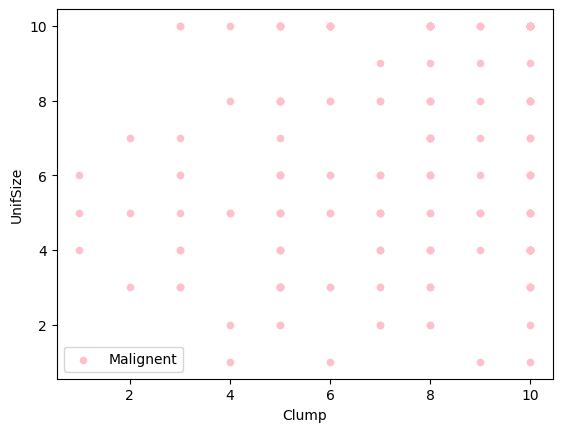

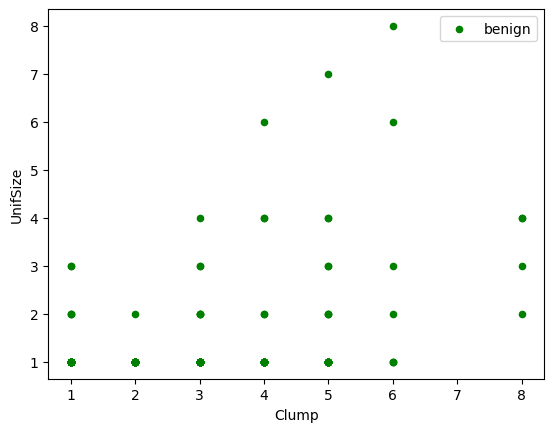

In [10]:
malignent.plot(kind="scatter", x="Clump", y="UnifSize", color="pink",label="Malignent")
benign.plot(kind="scatter", x="Clump", y="UnifSize", color="green",label="benign")

<Axes: xlabel='Clump', ylabel='UnifSize'>

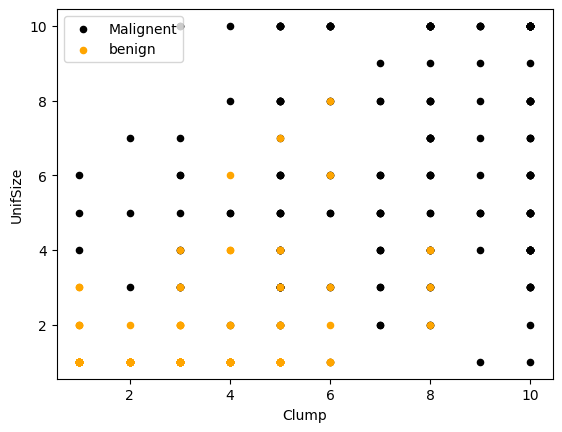

In [11]:
axes = malignent.plot(kind="scatter", x="Clump", y="UnifSize", color="black",label="Malignent")
benign.plot(kind="scatter", x="Clump", y="UnifSize", color="orange",label="benign",ax=axes)

In [12]:
dataset.dtypes

,0
ID,int64
Clump,int64
UnifSize,int64
UnifShape,int64
MargAdh,int64
SingEpiSize,int64
BareNuc,object
BlandChrom,int64
NormNucl,int64
Mit,int64


In [13]:
dataset["BareNuc"]

,BareNuc
0,1
1,10
2,2
3,4
4,1
...,...
694,2
695,1
696,3
697,4


In [14]:
list(dataset["BareNuc"])

['1',
 '10',
 '2',
 '4',
 '1',
 '10',
 '10',
 '1',
 '1',
 '1',
 '1',
 '1',
 '3',
 '3',
 '9',
 '1',
 '1',
 '1',
 '10',
 '1',
 '10',
 '7',
 '1',
 '?',
 '1',
 '7',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '5',
 '1',
 '1',
 '1',
 '1',
 '1',
 '10',
 '7',
 '?',
 '3',
 '10',
 '1',
 '1',
 '1',
 '9',
 '1',
 '1',
 '8',
 '3',
 '4',
 '5',
 '8',
 '8',
 '5',
 '6',
 '1',
 '10',
 '2',
 '3',
 '2',
 '8',
 '2',
 '1',
 '2',
 '1',
 '10',
 '9',
 '1',
 '1',
 '2',
 '1',
 '10',
 '4',
 '2',
 '1',
 '1',
 '3',
 '1',
 '1',
 '1',
 '1',
 '2',
 '9',
 '4',
 '8',
 '10',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '1',
 '6',
 '10',
 '5',
 '5',
 '1',
 '3',
 '1',
 '3',
 '10',
 '10',
 '1',
 '9',
 '2',
 '9',
 '10',
 '8',
 '3',
 '5',
 '2',
 '10',
 '3',
 '2',
 '1',
 '2',
 '10',
 '10',
 '7',
 '1',
 '10',
 '1',
 '10',
 '1',
 '1',
 '1',
 '10',
 '1',
 '1',
 '2',
 '1',
 '1',
 '1',
 '?',
 '1',
 '1',
 '5',
 '5',
 '1',
 '?',
 '8',
 '2',
 '1',
 '10',
 '1',
 '10',
 '5',
 '3',
 '1',
 '10',
 '1',
 '1',
 '?',
 '10',
 '10',
 '1',
 '

In [15]:
dataset["BareNuc"].isnull().sum()

np.int64(0)

In [16]:
dataset = dataset[pd.to_numeric(dataset["BareNuc"],errors = "coerce").notnull()]
dataset.BareNuc = dataset.BareNuc.astype("int")

In [17]:
dataset.dtypes

,0
ID,int64
Clump,int64
UnifSize,int64
UnifShape,int64
MargAdh,int64
SingEpiSize,int64
BareNuc,int64
BlandChrom,int64
NormNucl,int64
Mit,int64


In [18]:
dataset.columns

Index(['ID', 'Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize',
       'BareNuc', 'BlandChrom', 'NormNucl', 'Mit', 'Class'],
      dtype='object')

In [19]:
X_df=dataset[['ID', 'Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize',
       'BareNuc', 'BlandChrom', 'NormNucl', 'Mit']]

In [20]:
X = np.asarray(X_df)
y= np.asarray(dataset["Class"])

In [21]:
X[0:5]

array([[1000025,       5,       1,       1,       1,       2,       1,
              3,       1,       1],
       [1002945,       5,       4,       4,       5,       7,      10,
              3,       2,       1],
       [1015425,       3,       1,       1,       1,       2,       2,
              3,       1,       1],
       [1016277,       6,       8,       8,       1,       3,       4,
              3,       7,       1],
       [1017023,       4,       1,       1,       3,       2,       1,
              3,       1,       1]])

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=20)

In [23]:
from sklearn import svm
classifier = svm.SVC(kernel="linear", gamma="auto", C=2)

In [24]:
classifier.fit(X_train,y_train)

SVC(C=2, gamma='auto', kernel='linear')

In [25]:
y_pred = classifier.predict(X_test)
y_pred

array([2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2,
       2, 4, 4, 2, 2, 2, 2, 4, 2, 4, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4,
       2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2])

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.74      0.94      0.83        99
           4       0.50      0.16      0.24        38

    accuracy                           0.72       137
   macro avg       0.62      0.55      0.54       137
weighted avg       0.68      0.72      0.67       137

